In [1]:
import pickle

In [2]:
with open('grid_search.pkl', 'rb') as f:
    model = pickle.load(f)

In [3]:
model

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1),
             param_grid=[{'max_depth': [2, 4, 6, 8, 10],
                          'max_features': [1, 3, 5, 6],
                          'n_estimators': [50, 100, 150, 200, 250, 300, 350]}],
             return_train_score=True, scoring='r2')

In [4]:
model.best_estimator_

RandomForestRegressor(max_depth=10, max_features=6, n_estimators=350, n_jobs=-1)

In [5]:
model.cv_results_

{'mean_fit_time': array([0.06890187, 0.11380749, 0.16883659, 0.21107287, 0.24783287,
        0.2975266 , 0.34992232, 0.07776365, 0.13976498, 0.20337367,
        0.24725947, 0.31051545, 0.37484741, 0.44225039, 0.08834753,
        0.15846372, 0.2319654 , 0.30299559, 0.37197618, 0.45125284,
        0.52829628, 0.09847736, 0.18558221, 0.28267899, 0.37287331,
        0.45395842, 0.55089865, 0.63976822, 0.08020501, 0.14128809,
        0.21968346, 0.27380643, 0.33994036, 0.40242081, 0.46990652,
        0.10906858, 0.19613485, 0.29277587, 0.37910295, 0.48405385,
        0.56973643, 0.77065926, 0.15362406, 0.31861763, 0.41762137,
        0.54608769, 0.68348436, 0.81578331, 0.96160355, 0.17120657,
        0.32660956, 0.47983885, 0.66055589, 0.80027609, 0.96140532,
        1.10079398, 0.09612818, 0.16830106, 0.23840141, 0.31385183,
        0.39225478, 0.47854204, 0.58858237, 0.15376391, 0.28163095,
        0.4195302 , 0.53953815, 0.6829937 , 0.81373515, 0.93370609,
        0.2153223 , 0.41352215,

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
height = np.random.normal(160, 20, 1000)
bias = np.random.normal(10, 3, 1000)
weight = 0.3 * height + bias

In [8]:
bias.mean()

10.048582523115329

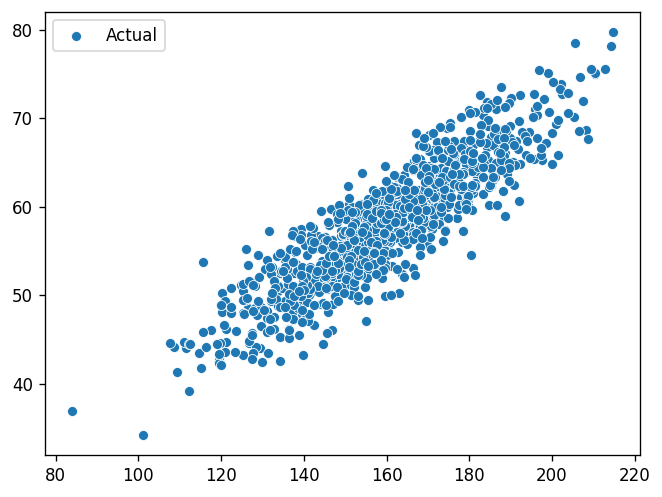

In [9]:
plt.figure(dpi=120)
sns.scatterplot(x=height, y=weight, label='Actual')
plt.show()

In [10]:
t0 = np.random.random() * 3
t1 = np.random.random()

In [11]:
print(t0)
print(t1)

1.4362222258722532
0.0659121069048213


In [12]:
y_pred = t1 * height + t0

In [13]:
y_pred

array([10.59162973, 12.39726836, 11.43727708, 10.6852816 , 11.70448728,
       12.15764824, 13.40548437, 14.3791644 , 13.28937354, 13.80879705,
       11.8171091 , 11.71180876, 10.8016745 , 13.86320925, 12.01730853,
       11.56476133, 12.25972789, 10.89755833, 12.62160717,  9.99938135,
       11.46679546,  9.33082609, 12.29737234, 13.58639068, 12.89841408,
       10.5357235 , 12.25619005,  9.96744634, 12.22155642, 11.93077536,
       12.85957889, 12.42682042,  9.35985226, 11.12543625, 13.74790863,
       12.80117093, 11.80608857, 11.61744054, 11.95218313, 10.51234544,
       11.30135737, 12.59248387,  9.65722965, 10.98031698, 10.88150152,
       11.14177715, 12.33164833, 12.82680839, 13.58494882, 12.94791273,
       15.16519727, 11.6687926 , 11.7190111 , 11.73524886, 14.54912084,
       12.95046391, 11.30528643, 10.53965326, 13.41144157, 13.04708027,
       11.65482209, 13.645941  , 12.25700495, 12.06941338, 11.76274602,
       12.87515052, 12.43711686, 13.24433522, 12.22396843, 12.82

In [14]:
from sklearn.metrics import mean_squared_error

Error = 2149.65


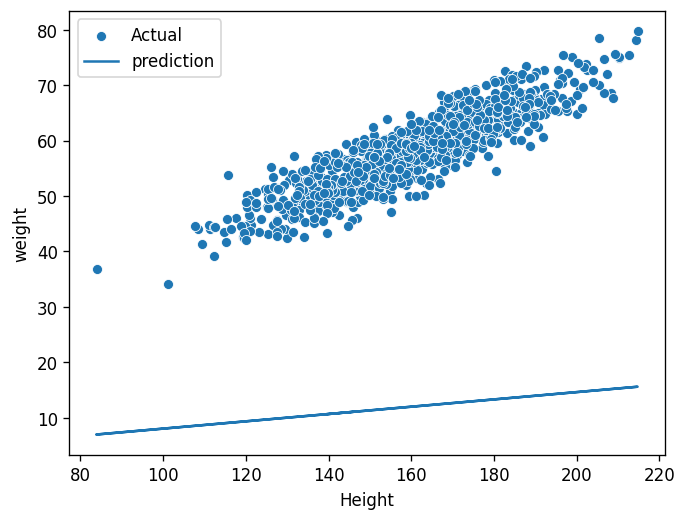

In [15]:
plt.figure(dpi=120)
sns.scatterplot(x=height, y=weight, label='Actual')
plt.xlabel('Height')
plt.ylabel('weight')
plt.plot(height, y_pred, label='prediction')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")
plt.legend()
plt.show()

In [16]:
grad_t0 = (y_pred - weight).sum() / len(weight)
grad_t1 = ((y_pred - weight) * height).sum() / len(weight)

In [17]:
grad_t0

-46.016848043363304

In [18]:
grad_t1

-7446.724463142194

In [19]:
t0

1.4362222258722532

In [20]:
t1

0.0659121069048213

In [21]:
t0_next = t0 - grad_t0
t1_next = t1 - grad_t1

In [22]:
t0_next

47.45307026923555

In [23]:
t1_next

7446.790375249098

Error = 2149.65
Error = 1437467350867.86


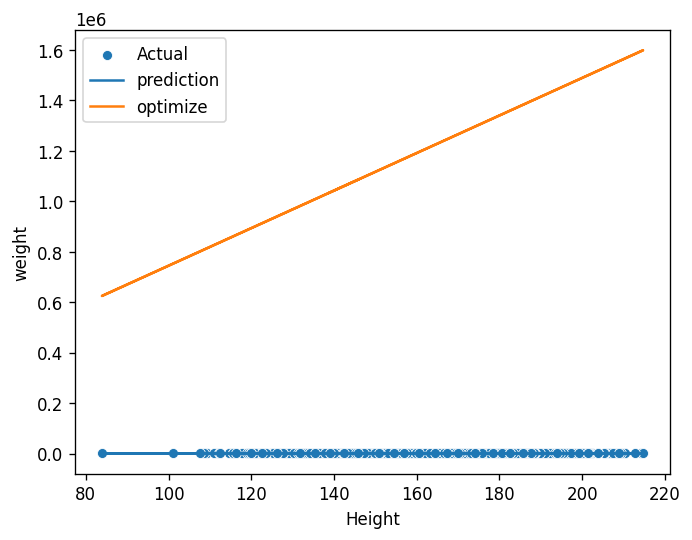

In [24]:
plt.figure(dpi=120)
sns.scatterplot(x=height, y=weight, label='Actual')
plt.xlabel('Height')
plt.ylabel('weight')
plt.plot(height, y_pred, label='prediction')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")

y_pred = t1_next * height + t0_next
plt.plot(height, y_pred, label='optimize')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")

plt.legend()
plt.show()

Error = 2149.65
Error = 142650859.23


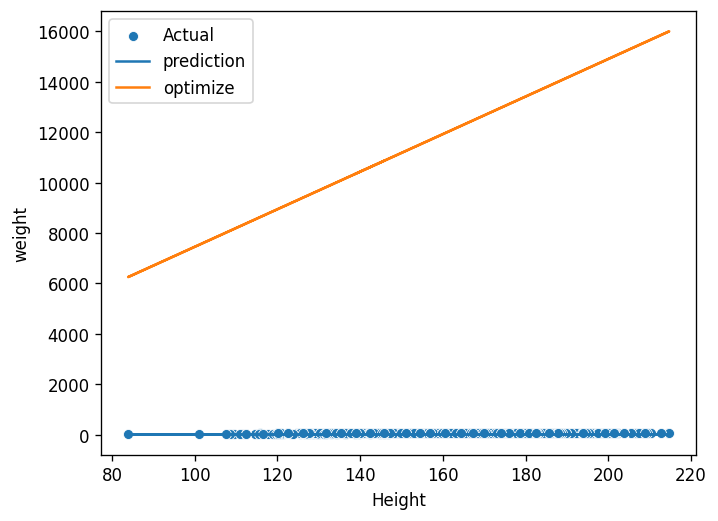

In [25]:
eta = 0.01
plt.figure(dpi=120)
sns.scatterplot(x=height, y=weight, label='Actual')
plt.xlabel('Height')
plt.ylabel('weight')

y_pred = t1 * height + t0
plt.plot(height, y_pred, label='prediction')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")

grad_t1 = ((y_pred - weight) * height).sum() / len(weight)
grad_t0 = (y_pred - weight).sum() / len(weight)

t0_next = t0 - eta * grad_t0
t1_next = t1 - eta * grad_t1

y_pred = t1_next * height + t0_next
plt.plot(height, y_pred, label='optimize')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")

plt.legend()
plt.show()

Error = 2149.65
Error = 1328816.26


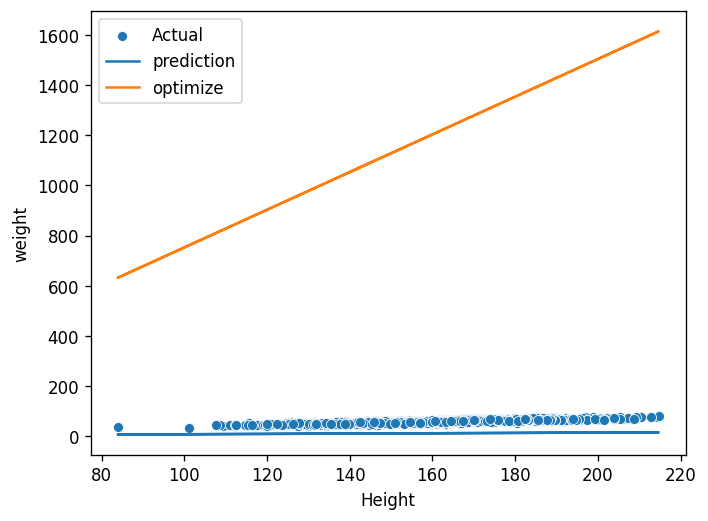

In [26]:
eta = 0.001
plt.figure(dpi=120)
sns.scatterplot(x=height, y=weight, label='Actual')
plt.xlabel('Height')
plt.ylabel('weight')

y_pred = t1 * height + t0
plt.plot(height, y_pred, label='prediction')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")

grad_t1 = ((y_pred - weight) * height).sum() / len(weight)
grad_t0 = (y_pred - weight).sum() / len(weight)

t0_next = t0 - eta * grad_t0
t1_next = t1 - eta * grad_t1

y_pred = t1_next * height + t0_next
plt.plot(height, y_pred, label='optimize')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")

plt.legend()
plt.show()

Error = 2149.65
Error = 5434.27


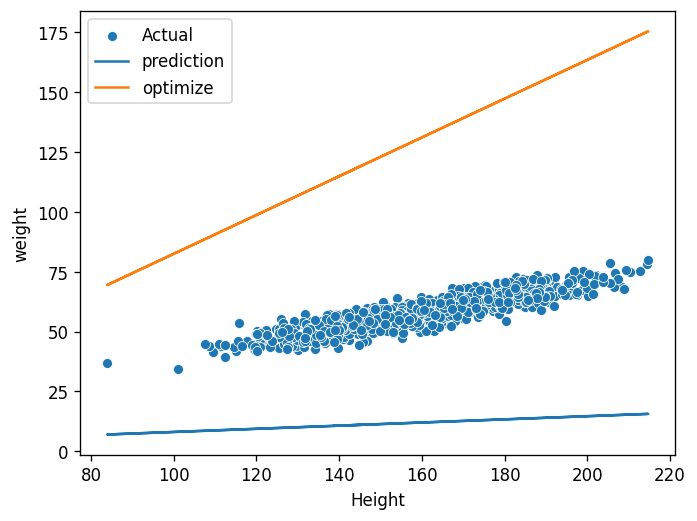

In [27]:
eta = 0.0001
plt.figure(dpi=120)
sns.scatterplot(x=height, y=weight, label='Actual')
plt.xlabel('Height')
plt.ylabel('weight')

y_pred = t1 * height + t0
plt.plot(height, y_pred, label='prediction')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")

grad_t1 = ((y_pred - weight) * height).sum() / len(weight)
grad_t0 = (y_pred - weight).sum() / len(weight)

t0_next = t0 - eta * grad_t0
t1_next = t1 - eta * grad_t1

y_pred = t1_next * height + t0_next
plt.plot(height, y_pred, label='optimize')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")

plt.legend()
plt.show()

Error = 2149.65
Error = 1184.29
Error = 654.56


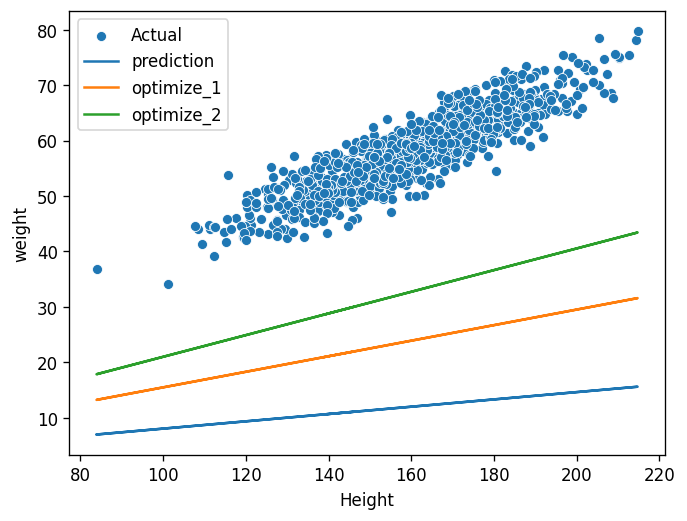

In [28]:
eta = 0.00001
plt.figure(dpi=120)
sns.scatterplot(x=height, y=weight, label='Actual')
plt.xlabel('Height')
plt.ylabel('weight')

y_pred = t1 * height + t0
plt.plot(height, y_pred, label='prediction')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")

grad_t1 = ((y_pred - weight) * height).sum() / len(weight)
grad_t0 = (y_pred - weight).sum() / len(weight)

t0_next = t0 - eta * grad_t0
t1_next = t1 - eta * grad_t1

y_pred = t1_next * height + t0_next
plt.plot(height, y_pred, label='optimize_1')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")


grad_t1 = ((y_pred - weight) * height).sum() / len(weight)
grad_t0 = (y_pred - weight).sum() / len(weight)

t0_next2 = t0_next - eta * grad_t0
t1_next2 = t1_next - eta * grad_t1

y_pred = t1_next2 * height + t0_next2
plt.plot(height, y_pred, label='optimize_2')
print(f"Error = {mean_squared_error(weight, y_pred):.2f}")

plt.legend()
plt.show()

Error = 4203.38
Error = 2311.12
Error = 1272.75
Error = 702.96
Error = 390.29
Error = 218.71
Error = 124.56
Error = 72.90
Error = 44.55
Error = 28.99
Error = 20.46
Error = 15.77
Error = 13.20
Error = 11.79
Error = 11.02
Error = 10.59
Error = 10.36
Error = 10.23
Error = 10.16
Error = 10.12
Error = 10.10
Error = 10.09
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10.08
Error = 10

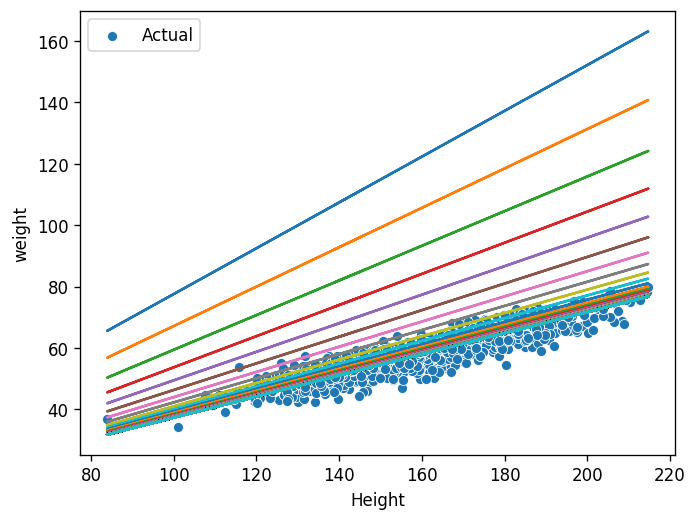

In [29]:
eta = 0.00001
max_iter = 1000

t0 = np.random.random() * 3
t1 = np.random.random()

plt.figure(dpi=120)
sns.scatterplot(x=height, y=weight, label='Actual')
plt.xlabel('Height')
plt.ylabel('weight')
y_pred = t1 * height + t0

for i in range(max_iter):
    grad_t1 = ((y_pred - weight) * height).sum() / len(weight)
    grad_t0 = (y_pred - weight).sum() / len(weight)

    t0 = t0 - eta * grad_t0
    t1 = t1 - eta * grad_t1
    
    y_pred = t1 * height + t0
    print(f"Error = {mean_squared_error(weight, y_pred):.2f}")
    plt.plot(height, y_pred, label=f"{i}")
    
# plt.legend()   
plt.show()  


Error = 5791.71
Error = 5499.58
Error = 5222.22
Error = 4958.86
Error = 4708.82
Error = 4471.41
Error = 4246.00
Error = 4031.98
Error = 3828.77
Error = 3635.83


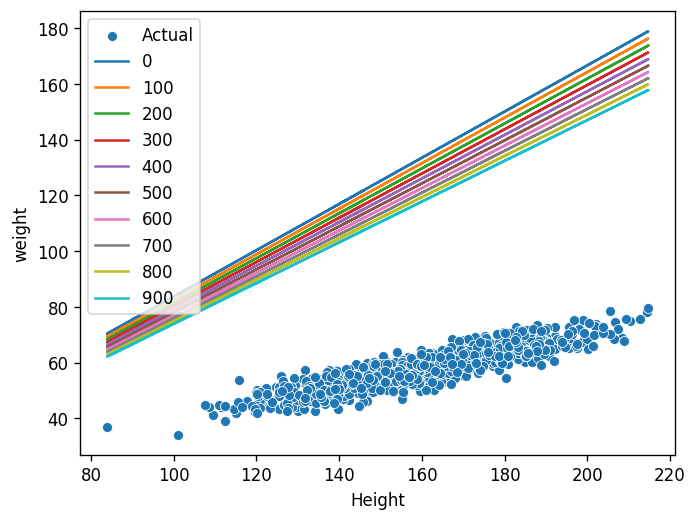

In [30]:
eta = 0.00000001
max_iter = 1000

t0 = np.random.random() * 3
t1 = np.random.random()

plt.figure(dpi=120)
sns.scatterplot(x=height, y=weight, label='Actual')
plt.xlabel('Height')
plt.ylabel('weight')
y_pred = t1 * height + t0

for i in range(max_iter):
    grad_t1 = ((y_pred - weight) * height).sum() / len(weight)
    grad_t0 = (y_pred - weight).sum() / len(weight)

    t0 = t0 - eta * grad_t0
    t1 = t1 - eta * grad_t1
    
    y_pred = t1 * height + t0
    if i % 100 == 0:
        print(f"Error = {mean_squared_error(weight, y_pred):.2f}")
        plt.plot(height, y_pred, label=f"{i}")
        
plt.legend()   
plt.show()  


In [31]:
height

array([138.9032749 , 166.29791782, 151.73319933, 140.3241348 ,
       155.78723754, 162.66246855, 181.59428826, 196.36668871,
       179.83268734, 187.71323514, 157.49590412, 155.898317  ,
       142.09001525, 188.53876179, 160.5332738 , 153.66735461,
       164.21119229, 143.54473785, 169.70152327, 129.91784852,
       152.18104394, 119.7747156 , 164.78232344, 184.33894816,
       173.90116003, 138.05508129, 164.15751723, 129.43333959,
       163.63206555, 159.22041674, 173.31196346, 166.74627338,
       120.21509254, 147.00203776, 186.78945309, 172.42581421,
       157.32870384, 154.46658878, 159.54520947, 137.70039592,
       149.67106357, 169.2596728 , 124.72681891, 144.80032887,
       143.30112839, 147.2499572 , 165.30234908, 172.81477869,
       184.31707268, 174.6521397 , 208.29215887, 155.24568792,
       156.00758877, 156.25394357, 198.9452201 , 174.69084554,
       149.73067413, 138.11470253, 181.68466934, 176.15668174,
       155.0337312 , 185.24242891, 164.16988058, 161.32

In [32]:
weight

array([49.91702158, 64.07989233, 51.08478484, 47.5616558 , 54.67215756,
       54.84583826, 63.66980537, 67.76384002, 59.96634812, 73.48168075,
       58.96909093, 56.88480209, 56.63680697, 66.05344675, 62.48618276,
       54.12381646, 61.1297606 , 56.68769723, 55.62557005, 42.47104693,
       52.40365006, 44.3235239 , 59.56490252, 66.91357093, 60.26537703,
       49.44283471, 56.11367767, 43.98011279, 52.37716321, 56.90207537,
       60.19607505, 65.11879139, 50.22587586, 53.68919027, 66.51423627,
       63.53210683, 55.27986913, 53.85729467, 49.92089592, 52.54246888,
       51.05978282, 64.3236393 , 51.1954296 , 52.1695087 , 50.63719263,
       54.43060581, 59.40457744, 58.69821914, 66.73704723, 59.9063505 ,
       68.67513178, 56.51910046, 58.85330924, 56.79772985, 75.1198198 ,
       68.92226488, 56.2622991 , 53.47158511, 63.99405333, 62.57140801,
       53.64291731, 67.89194404, 59.04795092, 53.29312699, 56.16849556,
       58.97648947, 60.1010095 , 63.92499032, 57.31086908, 60.71

In [33]:
from sklearn.linear_model import SGDRegressor

In [34]:
sgd = SGDRegressor(max_iter=1000, eta0=0.001, tol=0.001, early_stopping=True)

In [35]:
sgd

SGDRegressor(early_stopping=True, eta0=0.001)

In [36]:
X = height.reshape(-1,1)
X

array([[138.9032749 ],
       [166.29791782],
       [151.73319933],
       [140.3241348 ],
       [155.78723754],
       [162.66246855],
       [181.59428826],
       [196.36668871],
       [179.83268734],
       [187.71323514],
       [157.49590412],
       [155.898317  ],
       [142.09001525],
       [188.53876179],
       [160.5332738 ],
       [153.66735461],
       [164.21119229],
       [143.54473785],
       [169.70152327],
       [129.91784852],
       [152.18104394],
       [119.7747156 ],
       [164.78232344],
       [184.33894816],
       [173.90116003],
       [138.05508129],
       [164.15751723],
       [129.43333959],
       [163.63206555],
       [159.22041674],
       [173.31196346],
       [166.74627338],
       [120.21509254],
       [147.00203776],
       [186.78945309],
       [172.42581421],
       [157.32870384],
       [154.46658878],
       [159.54520947],
       [137.70039592],
       [149.67106357],
       [169.2596728 ],
       [124.72681891],
       [144

In [37]:
y = weight

In [38]:
sgd.fit(X, y)

SGDRegressor(early_stopping=True, eta0=0.001)

In [39]:
y_hat = np.round(sgd.predict(X), 2)
y_hat

array([-1.63449085e+12, -1.95699220e+12, -1.78553016e+12, -1.65121781e+12,
       -1.83325601e+12, -1.91419415e+12, -2.13706756e+12, -2.31097452e+12,
       -2.11632924e+12, -2.20910239e+12, -1.85337116e+12, -1.83456369e+12,
       -1.67200651e+12, -2.21882084e+12, -1.88912837e+12, -1.80829985e+12,
       -1.93242638e+12, -1.68913212e+12, -1.99706088e+12, -1.52871060e+12,
       -1.79080238e+12, -1.40930134e+12, -1.93914998e+12, -2.16937886e+12,
       -2.04650079e+12, -1.62450555e+12, -1.93179450e+12, -1.52300676e+12,
       -1.92560866e+12, -1.87367286e+12, -2.03956452e+12, -1.96227043e+12,
       -1.41448564e+12, -1.72983292e+12, -2.19822724e+12, -2.02913239e+12,
       -1.85140281e+12, -1.81770878e+12, -1.87749645e+12, -1.62033005e+12,
       -1.76125382e+12, -1.99185923e+12, -1.46759960e+12, -1.70391347e+12,
       -1.68626425e+12, -1.73275153e+12, -1.94527194e+12, -2.03371145e+12,
       -2.16912133e+12, -2.05534164e+12, -2.45136621e+12, -1.82688066e+12,
       -1.83585008e+12, -

In [40]:
from sklearn.metrics import mean_squared_error as mse

In [41]:
mse(y, y_hat)

3.5897499291149567e+24

### polynomial regression
                          y = ax**2 + bx + c

### linear equation
    y = mx + c
    

In [44]:
from sklearn.linear_model import SGDRegressor

In [46]:
SGDRegressor()

SGDRegressor()